## Part 1: Data Preparation

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Combine Features and Target
df = pd.concat([X, y], axis=1)

In [2]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN,no
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,NaN,5,may,380,1,-1,0,NaN,no
8,58,retired,married,primary,no,121,yes,no,NaN,5,may,50,1,-1,0,NaN,no
9,43,technician,single,secondary,no,593,yes,no,NaN,5,may,55,1,-1,0,NaN,no


In [3]:
df.shape

(45211, 17)

### Column names and data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

### Missing values and duplicates

In [6]:
df.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

In [7]:
df.duplicated().sum()

0

### Statistical summary

In [8]:
df.describe(include= "all")

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,44923,45211,43354,45211,45211.000000,45211,45211,32191,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,8252,45211
unique,NaN,11,3,3,2,NaN,2,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,failure,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,4901,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Distribution of target variable y

In [9]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [10]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

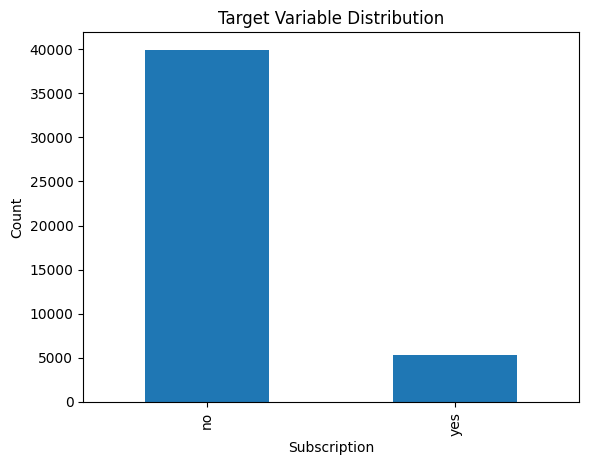

In [11]:
import matplotlib.pyplot as plt

df["y"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

### Identify columns containing unknown

In [12]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", (df[col] == "unknown").sum())

job : 0
marital : 0
education : 0
default : 0
housing : 0
loan : 0
contact : 0
month : 0
poutcome : 0
y : 0


In [13]:
for col in df.select_dtypes(include="object").columns:
    count = (df[col] == "unknown").sum()
    percentage = count / len(df) * 100
    print(f"{col}: {count} ({percentage:.2f}%)")

job: 0 (0.00%)
marital: 0 (0.00%)
education: 0 (0.00%)
default: 0 (0.00%)
housing: 0 (0.00%)
loan: 0 (0.00%)
contact: 0 (0.00%)
month: 0 (0.00%)
poutcome: 0 (0.00%)
y: 0 (0.00%)


### Handle unknown

In [14]:
df_clean = df.copy()

df_clean = df_clean.replace("unknown", np.nan)

In [15]:
df_clean.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

### Numerical columns

In [16]:
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

numerical_cols

Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')

In [17]:
for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

### Categorical columns

In [18]:
categorical_cols = df_clean.select_dtypes(include="object").columns

categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [19]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [20]:
df_clean.isnull().sum().sum()

0

### Check invalid or unusual values

In [21]:
df_clean.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [22]:
df_clean["age"].min(), df_clean["age"].max()

(18, 95)

In [23]:
df_clean["balance"].min(), df_clean["balance"].max()

(-8019, 102127)

In [24]:
df_clean["duration"].min(), df_clean["duration"].max()

(0, 4918)

### check duplicates

In [25]:
df_clean.duplicated().sum()

0

In [26]:
df_clean = df_clean.drop_duplicates()

In [27]:
df_clean.shape

(45211, 17)

## Part 2 — Feature Engineering

In [28]:
X = df_clean.drop("y", axis=1)
y = df_clean["y"]

In [29]:
y = y.map({"yes": 1, "no": 0})

In [30]:
y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [31]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [32]:
X = X.drop("duration", axis=1)

In [33]:
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

### Split Dataset

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 15)
X_test: (9043, 15)
y_train: (36168,)
y_test: (9043,)


In [36]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)

In [39]:
X_test_processed = preprocessor.transform(X_test)

In [40]:
preprocessor.fit_transform(X_test)

array([[-0.10478717, -0.24065683, -0.93675426, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.27315296, -0.3295392 ,  1.71890455, ...,  1.        ,
         0.        ,  0.        ],
       [-0.95515246, -0.3370026 ,  0.51178691, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.86066742, -0.13074123,  0.75321044, ...,  1.        ,
         0.        ,  0.        ],
       [-1.9944878 , -0.45777407, -1.66102484, ...,  1.        ,
         0.        ,  0.        ],
       [-0.1992722 , -0.33462788, -0.57461897, ...,  1.        ,
         0.        ,  0.        ]])

### Part 3 — Logistic Regression + Decision Tree + Random Forest + AdaBoost

In [41]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
y_train_pred_log = log_model.predict(X_train_processed)
y_test_pred_log = log_model.predict(X_test_processed)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [44]:
evaluate_model(
    y_train,
    y_train_pred_log,
    "Logistic Regression - Training")

--- Logistic Regression - Training ---
Accuracy : 0.8925
Precision: 0.6516
Recall   : 0.1742
F1-score : 0.2749

Confusion Matrix:
[[31543   394]
 [ 3494   737]]


In [45]:
evaluate_model(
    y_test,
    y_test_pred_log,
    "Logistic Regression - Testing"
)

--- Logistic Regression - Testing ---
Accuracy : 0.8936
Precision: 0.6702
Recall   : 0.1786
F1-score : 0.2821

Confusion Matrix:
[[7892   93]
 [ 869  189]]


### Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
y_train_pred_dt = dt_model.predict(X_train_processed)
y_test_pred_dt = dt_model.predict(X_test_processed)

In [48]:
evaluate_model(
    y_train,
    y_train_pred_dt,
    "Decision Tree - Training"
)

evaluate_model(
    y_test,
    y_test_pred_dt,
    "Decision Tree - Testing"
)

--- Decision Tree - Training ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 0.9998
F1-score : 0.9999

Confusion Matrix:
[[31937     0]
 [    1  4230]]
--- Decision Tree - Testing ---
Accuracy : 0.8306
Precision: 0.2950
Recall   : 0.3223
F1-score : 0.3080

Confusion Matrix:
[[7170  815]
 [ 717  341]]


### Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [50]:
y_train_pred_rf = rf_model.predict(X_train_processed)
y_test_pred_rf = rf_model.predict(X_test_processed)

In [51]:
evaluate_model(
    y_train,
    y_train_pred_rf,
    "Random Forest - Training"
)

evaluate_model(
    y_test,
    y_test_pred_rf,
    "Random Forest - Testing"
)

--- Random Forest - Training ---
Accuracy : 0.9999
Precision: 1.0000
Recall   : 0.9993
F1-score : 0.9996

Confusion Matrix:
[[31937     0]
 [    3  4228]]
--- Random Forest - Testing ---
Accuracy : 0.8937
Precision: 0.6286
Recall   : 0.2240
F1-score : 0.3303

Confusion Matrix:
[[7845  140]
 [ 821  237]]


### AdaBoost

In [52]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train_processed, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [53]:
y_train_pred_ada = ada_model.predict(X_train_processed)
y_test_pred_ada = ada_model.predict(X_test_processed)

In [54]:
y_train_pred_ada = ada_model.predict(X_train_processed)
y_test_pred_ada = ada_model.predict(X_test_processed)

### Compare the 4 Models

In [55]:
results = []

models = {
    "Logistic Regression": (
        y_train_pred_log,
        y_test_pred_log
    ),
    "Decision Tree": (
        y_train_pred_dt,
        y_test_pred_dt
    ),
    "Random Forest": (
        y_train_pred_rf,
        y_test_pred_rf
    ),
    "AdaBoost": (
        y_train_pred_ada,
        y_test_pred_ada
    )
}

for name, (train_pred, test_pred) in models.items():

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Logistic Regression,0.892502,0.893619,0.651636,0.670213,0.174190,0.178639,0.274897,0.282090
1,Decision Tree,0.999972,0.830587,1.000000,0.294983,0.999764,0.322306,0.999882,0.308040
2,Random Forest,0.999917,0.893730,1.000000,0.628647,0.999291,0.224008,0.999645,0.330314
3,AdaBoost,0.893221,0.890855,0.643357,0.619529,0.195698,0.173913,0.300109,0.271587


### Balanced or imbalanced?

In [56]:
y.value_counts(normalize=True) * 100

y
0    88.30152
1    11.69848
Name: proportion, dtype: float64

### How many customers incorrectly predicted as subscribers?

In [57]:
cm = confusion_matrix(y_test, y_test_pred_log)

TN, FP, FN, TP = cm.ravel()

print("False Positives:", FP)

False Positives: 93


### How many actual subscribers failed to identify?

print("False Negatives:", FN)

## Part 4 — Model Improvement

In [58]:
class_distribution = y.value_counts(normalize=True) * 100

print(class_distribution)

y
0    88.30152
1    11.69848
Name: proportion, dtype: float64


In [59]:
log_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_balanced.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [60]:
y_train_pred_balanced = log_balanced.predict(X_train_processed)
y_test_pred_balanced = log_balanced.predict(X_test_processed)

In [61]:
evaluate_model(
    y_test,
    y_test_pred_balanced,
    "Balanced Logistic Regression"
)

--- Balanced Logistic Regression ---
Accuracy : 0.7618
Precision: 0.2678
Recall   : 0.5974
F1-score : 0.3698

Confusion Matrix:
[[6257 1728]
 [ 426  632]]


In [62]:
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],

    "Original": [
        precision_score(y_test, y_test_pred_log),
        recall_score(y_test, y_test_pred_log),
        f1_score(y_test, y_test_pred_log)
    ],

    "Balanced": [
        precision_score(y_test, y_test_pred_balanced),
        recall_score(y_test, y_test_pred_balanced),
        f1_score(y_test, y_test_pred_balanced)
    ]
})

comparison

,Metric,Original,Balanced
0,Precision,0.670213,0.267797
1,Recall,0.178639,0.597353
2,F1-score,0.282090,0.369807


### Decision Threshold

In [63]:
y_test_proba = log_balanced.predict_proba(X_test_processed)[:, 1]

### Threshold = 0.3

In [64]:
threshold = 0.3

y_pred_03 = (y_test_proba >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_03))
print("Recall:", recall_score(y_test, y_pred_03))
print("F1:", f1_score(y_test, y_pred_03))

Precision: 0.14184397163120568
Recall: 0.9073724007561437
F1: 0.24533605928954766


### Threshold = 0.5

In [65]:
threshold = 0.5

y_pred_05 = (y_test_proba >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_05))
print("Recall:", recall_score(y_test, y_pred_05))
print("F1:", f1_score(y_test, y_pred_05))

Precision: 0.2677966101694915
Recall: 0.5973534971644613
F1: 0.3698069046225863


### Threshold = 0.7

In [66]:
threshold = 0.7

y_pred_07 = (y_test_proba >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_07))
print("Recall:", recall_score(y_test, y_pred_07))
print("F1:", f1_score(y_test, y_pred_07))

Precision: 0.5087483176312247
Recall: 0.3572778827977316
F1: 0.41976679622431984


### Compare thresholds

In [67]:
threshold_results = []

for threshold in [0.3, 0.5, 0.7]:

    y_pred = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-score
0,0.3,0.141844,0.907372,0.245336
1,0.5,0.267797,0.597353,0.369807
2,0.7,0.508748,0.357278,0.419767


## Part 5 — KNN

In [68]:
from sklearn.neighbors import KNeighborsClassifier

In [69]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

KNeighborsClassifier()

In [70]:
y_train_pred_knn = knn_model.predict(X_train_processed)
y_test_pred_knn = knn_model.predict(X_test_processed)

In [71]:
evaluate_model(
    y_train,
    y_train_pred_knn,
    "KNN - Training"
)

evaluate_model(
    y_test,
    y_test_pred_knn,
    "KNN - Testing"
)

--- KNN - Training ---
Accuracy : 0.9051
Precision: 0.7355
Recall   : 0.2945
F1-score : 0.4206

Confusion Matrix:
[[31489   448]
 [ 2985  1246]]
--- KNN - Testing ---
Accuracy : 0.8876
Precision: 0.5568
Recall   : 0.1947
F1-score : 0.2885

Confusion Matrix:
[[7821  164]
 [ 852  206]]


In [72]:
k_values = [3, 5, 7, 9, 11, 15]

knn_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_processed, y_train)

    y_pred = knn.predict(X_test_processed)

    knn_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

knn_results_df = pd.DataFrame(knn_results)

knn_results_df

,K,Accuracy,Precision,Recall,F1-score
0,3,0.882119,0.492218,0.239130,0.321883
1,5,0.887648,0.556757,0.194707,0.288515
2,7,0.889970,0.594595,0.187146,0.284687
3,9,0.890412,0.613559,0.171078,0.267554
4,11,0.892624,0.658182,0.171078,0.271568
5,15,0.891739,0.652510,0.159735,0.256644


## Part 6 — SVM

In [73]:
from sklearn.svm import SVC

In [74]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

SVC(random_state=42)

In [75]:
y_train_pred_svm = svm_model.predict(X_train_processed)
y_test_pred_svm = svm_model.predict(X_test_processed)

In [76]:
evaluate_model(
    y_train,
    y_train_pred_svm,
    "SVM - Training"
)

evaluate_model(
    y_test,
    y_test_pred_svm,
    "SVM - Testing"
)

--- SVM - Training ---
Accuracy : 0.8955
Precision: 0.6913
Recall   : 0.1926
F1-score : 0.3013

Confusion Matrix:
[[31573   364]
 [ 3416   815]]
--- SVM - Testing ---
Accuracy : 0.8932
Precision: 0.6533
Recall   : 0.1853
F1-score : 0.2887

Confusion Matrix:
[[7881  104]
 [ 862  196]]


### Compare All Models

In [77]:
final_results = []

all_models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "KNN": knn_model,
    "SVM": svm_model
}

for name, model in all_models.items():

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    final_results.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),

        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),

        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),

        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    "Test F1",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
2,Random Forest,0.999917,0.893730,1.000000,0.628647,0.999291,0.224008,0.999645,0.330314
1,Decision Tree,0.999972,0.830587,1.000000,0.294983,0.999764,0.322306,0.999882,0.308040
5,SVM,0.895488,0.893177,0.691264,0.653333,0.192626,0.185255,0.301294,0.288660
4,KNN,0.905082,0.887648,0.735537,0.556757,0.294493,0.194707,0.420591,0.288515
0,Logistic Regression,0.892502,0.893619,0.651636,0.670213,0.174190,0.178639,0.274897,0.282090
3,AdaBoost,0.893221,0.890855,0.643357,0.619529,0.195698,0.173913,0.300109,0.271587
